In [1]:
import os

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd

MLFLOW_URI = os.environ.get("MLFLOW_TRACKING_URI", "http://mlflow:5000")
mlflow.set_tracking_uri(MLFLOW_URI)

EXPERIMENT = "lab6_hyperparameter_tuning"
MODELS = ["linear_svc", "logistic_regression", "multinomial_nb"]
METHODS = ["grid_search", "random_search", "halving_grid_search", "halving_random_search"]
METHOD_LABELS = {
    "grid_search": "Grid",
    "random_search": "Random",
    "halving_grid_search": "HalvingGrid",
    "halving_random_search": "HalvingRandom",
}
MODEL_LABELS = {
    "linear_svc": "SVM",
    "logistic_regression": "LR",
    "multinomial_nb": "NaiveBayes",
}
COLORS = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

In [2]:
all_runs = mlflow.search_runs(experiment_names=[EXPERIMENT])

# numeric coercion
for col in all_runs.columns:
    if col.startswith("metrics.") or col == "params.n_candidates_total":
        all_runs[col] = pd.to_numeric(all_runs[col], errors="coerce")

best_runs = all_runs[all_runs["tags.is_best"] == "true"].copy()

print(f"Total runs: {len(all_runs)}")
print(f"Best runs:  {len(best_runs)}")

Total runs: 486
Best runs:  12


## 1. Best Results per Model × Method

In [3]:
RESULT_COLS = [
    "tags.model",
    "tags.method",
    "metrics.test_f1_macro",
    "metrics.test_f1_weighted",
    "metrics.test_accuracy",
    "metrics.test_precision",
    "metrics.test_recall",
    "metrics.fit_time_seconds",
]
available = [c for c in RESULT_COLS if c in best_runs.columns]
table = (
    best_runs[available]
    .rename(columns=lambda c: c.replace("tags.", "").replace("metrics.", ""))
    .sort_values(["model", "method"])
    .reset_index(drop=True)
)
display(table)

,model,method,test_f1_macro,test_f1_weighted,test_accuracy,test_precision,test_recall,fit_time_seconds
0,linear_svc,grid_search,0.8522,0.9102,0.9075,0.8337,0.8757,23.83
1,linear_svc,halving_grid_search,0.8522,0.9102,0.9075,0.8337,0.8757,8.62
2,linear_svc,halving_random_search,0.8522,0.9102,0.9075,0.8337,0.8757,4.91
3,linear_svc,random_search,0.8522,0.9102,0.9075,0.8337,0.8757,12.13
4,logistic_regression,grid_search,0.8528,0.9102,0.9072,0.8326,0.8790,2081.34
5,logistic_regression,halving_grid_search,0.8528,0.9102,0.9072,0.8326,0.8790,367.02
6,logistic_regression,halving_random_search,0.8304,0.8991,0.8979,0.8233,0.8381,18.36
7,logistic_regression,random_search,0.8418,0.9053,0.9038,0.8314,0.8536,20.51
8,multinomial_nb,grid_search,0.8260,0.8958,0.8941,0.8159,0.8376,11.71
9,multinomial_nb,halving_grid_search,0.8171,0.8868,0.8816,0.7941,0.8509,9.53


## 2. Test F1-macro Comparison

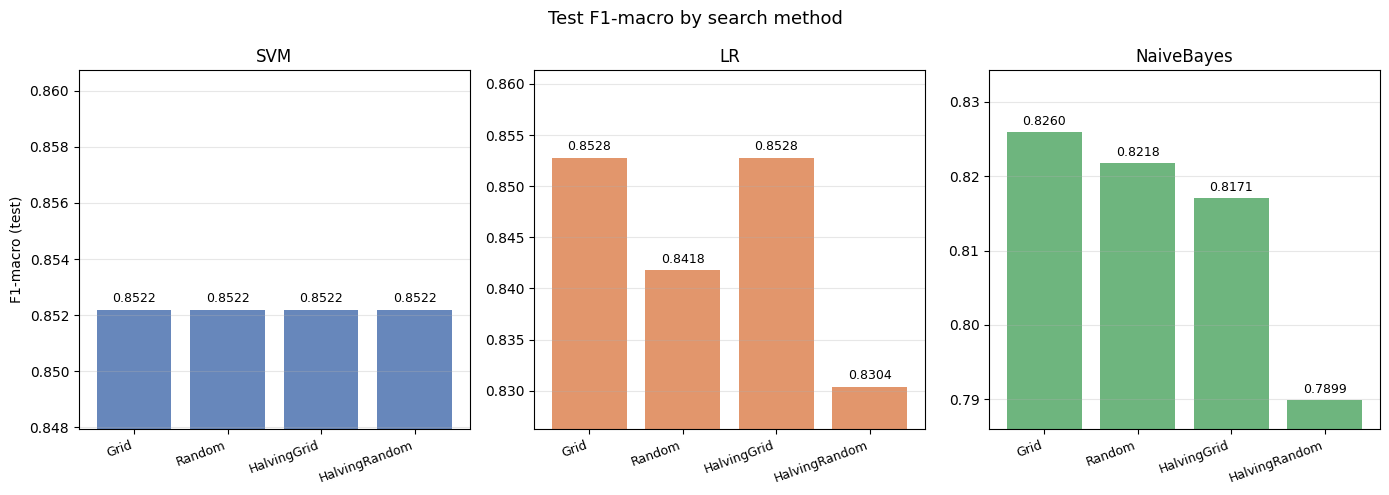

In [4]:
pivot_f1 = best_runs.pivot_table(
    index="tags.method", columns="tags.model", values="metrics.test_f1_macro"
).reindex(METHODS)[MODELS]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, model, color in zip(axes, MODELS, COLORS):
    vals = pivot_f1[model].values
    bars = ax.bar(range(len(METHODS)), vals, color=color, alpha=0.85)
    ax.bar_label(bars, fmt="%.4f", padding=3, fontsize=9)
    ax.set_xticks(range(len(METHODS)))
    ax.set_xticklabels([METHOD_LABELS[m] for m in METHODS], rotation=20, ha="right", fontsize=9)
    ax.set_title(MODEL_LABELS[model])
    ax.set_ylabel("F1-macro (test)" if ax == axes[0] else "")
    ymin = pivot_f1[model].min()
    ax.set_ylim(max(0, ymin * 0.995), pivot_f1[model].max() * 1.01)
    ax.grid(axis="y", alpha=0.3)
fig.suptitle("Test F1-macro by search method", fontsize=13)
plt.tight_layout()
plt.show()

## 3. Fit Time Comparison

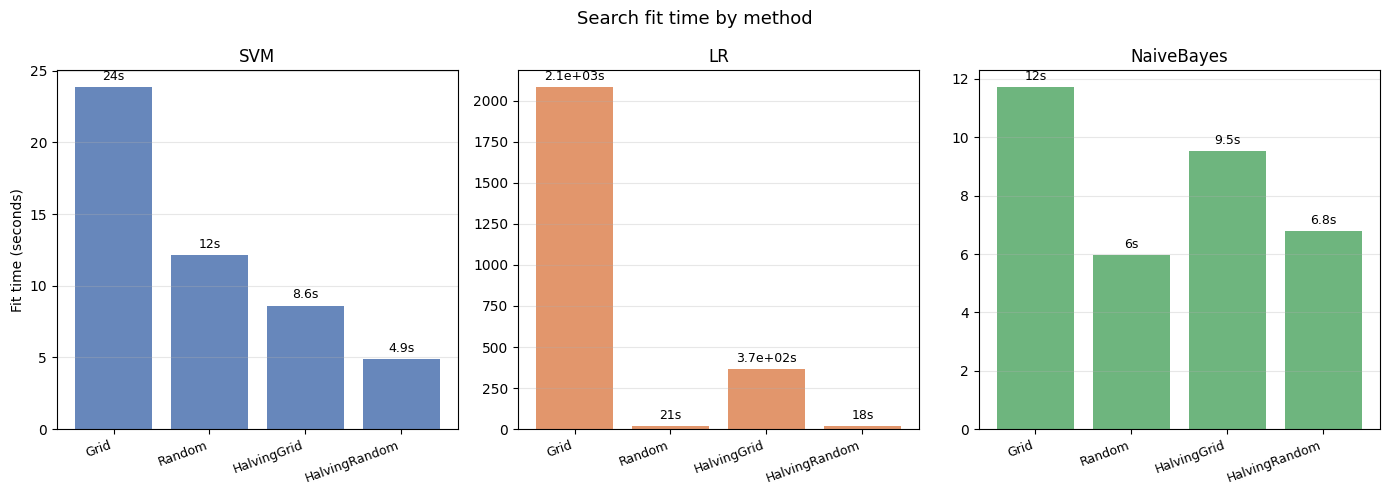

In [5]:
pivot_time = best_runs.pivot_table(
    index="tags.method", columns="tags.model", values="metrics.fit_time_seconds"
).reindex(METHODS)[MODELS]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, model, color in zip(axes, MODELS, COLORS):
    vals = pivot_time[model].values
    bars = ax.bar(range(len(METHODS)), vals, color=color, alpha=0.85)
    ax.bar_label(bars, fmt="%.2gs", padding=3, fontsize=9)
    ax.set_xticks(range(len(METHODS)))
    ax.set_xticklabels([METHOD_LABELS[m] for m in METHODS], rotation=20, ha="right", fontsize=9)
    ax.set_title(MODEL_LABELS[model])
    ax.set_ylabel("Fit time (seconds)" if ax == axes[0] else "")
    ax.grid(axis="y", alpha=0.3)
fig.suptitle("Search fit time by method", fontsize=13)
plt.tight_layout()
plt.show()

## 4. Number of Candidates (Iterations)

In [6]:
pivot_cand = best_runs.pivot_table(
    index="tags.method",
    columns="tags.model",
    values="params.n_candidates_total",
    aggfunc="first",
).reindex(METHODS)[MODELS]
pivot_cand.index = [METHOD_LABELS[m] for m in METHODS]
pivot_cand.columns = [MODEL_LABELS[m] for m in MODELS]
pivot_cand = pivot_cand.astype("Int64")
display(pivot_cand)

,SVM,LR,NaiveBayes
Grid,24,60,30
Random,10,10,10
HalvingGrid,35,90,46
HalvingRandom,35,90,46


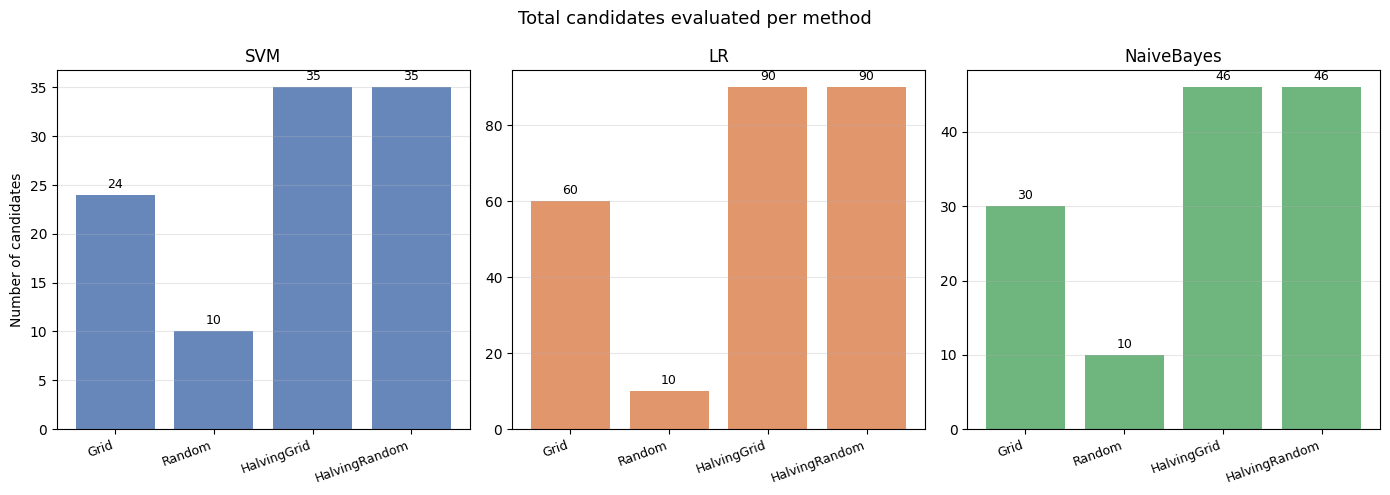

In [7]:
pivot_cand_raw = best_runs.pivot_table(
    index="tags.method",
    columns="tags.model",
    values="params.n_candidates_total",
    aggfunc="first",
).reindex(METHODS)[MODELS]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, model, color in zip(axes, MODELS, COLORS):
    vals = pivot_cand_raw[model].values
    bars = ax.bar(range(len(METHODS)), vals, color=color, alpha=0.85)
    ax.bar_label(bars, fmt="%d", padding=3, fontsize=9)
    ax.set_xticks(range(len(METHODS)))
    ax.set_xticklabels([METHOD_LABELS[m] for m in METHODS], rotation=20, ha="right", fontsize=9)
    ax.set_title(MODEL_LABELS[model])
    ax.set_ylabel("Number of candidates" if ax == axes[0] else "")
    ax.grid(axis="y", alpha=0.3)
fig.suptitle("Total candidates evaluated per method", fontsize=13)
plt.tight_layout()
plt.show()

## 5. CV Score Distribution Across All Candidates

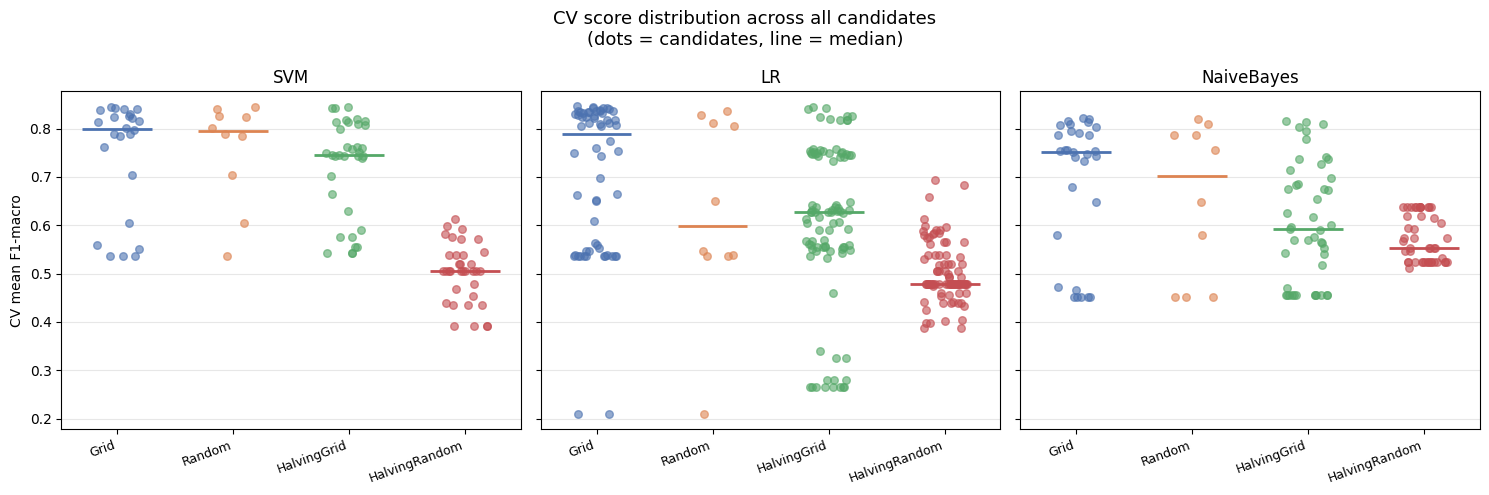

In [8]:
rng = np.random.default_rng(42)

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
for ax, model in zip(axes, MODELS):
    subset = all_runs[all_runs["tags.model"] == model]
    for xi, method in enumerate(METHODS):
        vals = subset[subset["tags.method"] == method]["metrics.cv_mean_f1_macro"].dropna().values
        if len(vals) == 0:
            continue
        jitter = rng.uniform(-0.2, 0.2, size=len(vals))
        ax.scatter(
            xi + jitter, vals,
            color=COLORS[xi], alpha=0.6, s=30, zorder=3,
        )
        median = np.median(vals)
        ax.hlines(median, xi - 0.3, xi + 0.3, colors=COLORS[xi], linewidths=2, zorder=4)
    ax.set_xticks(range(len(METHODS)))
    ax.set_xticklabels([METHOD_LABELS[m] for m in METHODS], rotation=20, ha="right", fontsize=9)
    ax.set_title(MODEL_LABELS[model])
    ax.set_ylabel("CV mean F1-macro" if ax == axes[0] else "")
    ax.grid(axis="y", alpha=0.3)
fig.suptitle("CV score distribution across all candidates\n(dots = candidates, line = median)", fontsize=13)
plt.tight_layout()
plt.show()

## 8. Efficiency: Test F1 vs Fit Time

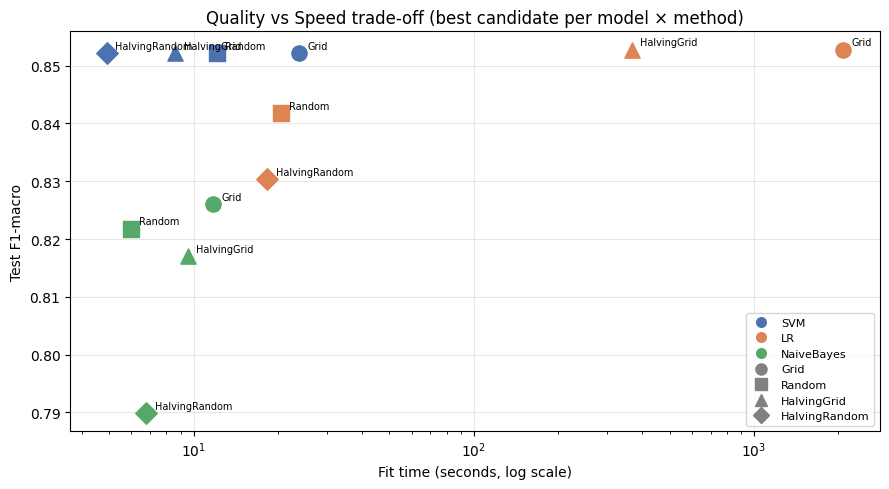

In [10]:
MARKERS = {
    "grid_search": "o",
    "random_search": "s",
    "halving_grid_search": "^",
    "halving_random_search": "D",
}

fig, ax = plt.subplots(figsize=(9, 5))
for model, color in zip(MODELS, COLORS):
    subset = best_runs[best_runs["tags.model"] == model]
    for method, marker in MARKERS.items():
        row = subset[subset["tags.method"] == method]
        if row.empty:
            continue
        t = float(row["metrics.fit_time_seconds"].values[0])
        f = float(row["metrics.test_f1_macro"].values[0])
        label = f"{MODEL_LABELS[model]} / {METHOD_LABELS[method]}"
        ax.scatter(t, f, color=color, marker=marker, s=120, zorder=3, label=label)
        ax.annotate(
            METHOD_LABELS[method],
            (t, f), textcoords="offset points", xytext=(6, 3), fontsize=7,
        )

ax.set_xscale("log")
ax.set_xlabel("Fit time (seconds, log scale)")
ax.set_ylabel("Test F1-macro")
ax.set_title("Quality vs Speed trade-off (best candidate per model × method)")
ax.grid(alpha=0.3)

# legend: deduplicate by model color patches + method markers
from matplotlib.lines import Line2D
legend_handles = []
for model, color in zip(MODELS, COLORS):
    legend_handles.append(Line2D([0], [0], marker="o", color="w", markerfacecolor=color,
                                  markersize=9, label=MODEL_LABELS[model]))
for method, marker in MARKERS.items():
    legend_handles.append(Line2D([0], [0], marker=marker, color="grey",
                                  markersize=8, linestyle="None", label=METHOD_LABELS[method]))
ax.legend(handles=legend_handles, fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()

## 9. Summary — Best Method per Model

In [11]:
summary_cols = [
    "tags.model", "tags.method",
    "metrics.test_f1_macro", "metrics.fit_time_seconds",
    "params.n_candidates_total",
]
available_summary = [c for c in summary_cols if c in best_runs.columns]
summary = (
    best_runs
    .sort_values(
        ["tags.model", "metrics.test_f1_macro", "metrics.fit_time_seconds"],
        ascending=[True, False, True],
    )
    .drop_duplicates("tags.model", keep="first")[available_summary]
    .rename(columns=lambda c: c.replace("tags.", "").replace("metrics.", "").replace("params.", ""))
    .reset_index(drop=True)
)
display(summary)

,model,method,test_f1_macro,fit_time_seconds,n_candidates_total
0,linear_svc,halving_random_search,0.8522,4.91,35
1,logistic_regression,halving_grid_search,0.8528,367.02,90
2,multinomial_nb,grid_search,0.8260,11.71,30


**(a) Quality vs. time.**

- **LinearSVC** — all four methods converge to the same optimum (`test_f1=0.8522`). The cost differs by ~5×: `HalvingRandom` 4.9 s, `HalvingGrid` 8.6 s, `Random` 12.1 s, `Grid` 23.8 s.
- **LogisticRegression** — `Grid` and `HalvingGrid` reach the best score (`0.8528`), but `Grid` takes **2081 s** vs. **367 s** for `HalvingGrid` (~5.7× speedup at identical quality). `Random`/`HalvingRandom` finish in ~20 s but leave ~1–2 pp of F1 on the table (0.8418 / 0.8304).
- **MultinomialNB** — `Grid` wins on quality (`0.8260`), the rest trail by 0.4–3.6 pp. Fit time is already low across the board (6–12 s), so halving gains little.

**(b) Number of models trained** (total candidates fitted across all CV splits; from `cv_results_`):

| Method | SVM | LR | NaiveBayes |
|---|---|---|---|
| Grid | 24 | 60 | 30 |
| Random | 10 | 10 | 10 |
| HalvingGrid | 35 | 90 | 46 |
| HalvingRandom | 35 | 90 | 46 |

Note: halving methods evaluate *more* candidates than grid, but most of them run on a small data subset 

**(c) Best method — `HalvingGridSearchCV`.** It matched `GridSearchCV` on quality for every model (same best estimator for SVM and LR, marginally worse for NB) while cutting fit time by **~3×–6×** — most dramatically on LR (2081 s → 367 s). `RandomizedSearchCV` is the fastest on paper but underexplores the grid and loses F1 on LR and NB. Full `GridSearchCV` is a poor use of compute here: it never beats halving on quality and is drastically slower. `HalvingRandomSearchCV` is the fastest option but its NB result (0.7899) shows the risk of combining two sources of randomness — random sampling + aggressive early stopping — when the grid is small. Overall, `HalvingGridSearchCV` offers the best quality-per-second trade-off and is my recommended default for this problem.